In [1]:
import glob, os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.ndimage import gaussian_filter

In [2]:
save_dir = "/g/data/m35/qr1706/PhD-1_CMIP_analysis/nc_models_fours-y-tout"

all_anoms = {
    'SON_yr1': {'tas': [], 'tos': [], 'ev': [], 'u850': [], 'v850': [], 'vimd': []},
    'SON_yr3': {'tas': [], 'tos': [], 'ev': [], 'u850': [], 'v850': [], 'vimd': []},
    'DJF_yr1': {'tas': [], 'tos': [], 'ev': [], 'u850': [], 'v850': [], 'vimd': []},
    'DJF_yr3': {'tas': [], 'tos': [], 'ev': [], 'u850': [], 'v850': [], 'vimd': []},
}

for tag in all_anoms.keys():
    files = sorted(glob.glob(os.path.join(save_dir, f"*_{tag}_anoms.nc")))
    print(f"\n{tag} : {len(files)} fichiers trouvés")
    for f in files:
        model_name = os.path.basename(f).replace(f"_{tag}_anoms.nc", "")
        ds = xr.open_dataset(f)
        for var in all_anoms[tag].keys():
            if var in ds:
                for yr in ds.event_year.values:
                    all_anoms[tag][var].append(ds[var].sel(event_year=yr))
        print(f"  -> {model_name} : {len(ds.event_year.values)} événements")
        ds.close()


SON_yr1 : 10 fichiers trouvés
  -> ACCESS-ESM1-5 : 10 événements
  -> EC-Earth3-Veg-LR : 7 événements
  -> EC-Earth3 : 8 événements
  -> GFDL-CM4 : 11 événements
  -> GFDL-ESM4 : 13 événements
  -> HadGEM3-GC31-LL : 8 événements
  -> MRI-ESM2-0 : 6 événements
  -> NorESM2-MM : 17 événements
  -> SAMO-UNICON : 18 événements
  -> UKESM1-0-LL : 36 événements

SON_yr3 : 10 fichiers trouvés
  -> ACCESS-ESM1-5 : 10 événements
  -> EC-Earth3-Veg-LR : 7 événements
  -> EC-Earth3 : 8 événements
  -> GFDL-CM4 : 11 événements
  -> GFDL-ESM4 : 13 événements
  -> HadGEM3-GC31-LL : 8 événements
  -> MRI-ESM2-0 : 6 événements
  -> NorESM2-MM : 17 événements
  -> SAMO-UNICON : 18 événements
  -> UKESM1-0-LL : 36 événements

DJF_yr1 : 10 fichiers trouvés
  -> ACCESS-ESM1-5 : 10 événements
  -> EC-Earth3-Veg-LR : 7 événements
  -> EC-Earth3 : 8 événements
  -> GFDL-CM4 : 11 événements
  -> GFDL-ESM4 : 13 événements
  -> HadGEM3-GC31-LL : 8 événements
  -> MRI-ESM2-0 : 6 événements
  -> NorESM2-MM : 17 

In [10]:
SEASON = 'DJF'  # Changer en 'DJF' si besoin
tag_yr1  = f'{SEASON}_yr1'
tag_yr3  = f'{SEASON}_yr3'
tag_diff = f'{SEASON}_diff'

seasonal_mmm = {tag_yr1: {}, tag_yr3: {}, tag_diff: {}}

for tag in [tag_yr1, tag_yr3]:
    for var in ['tas', 'tos', 'ev', 'u850', 'v850', 'vimd']:
        data_list = all_anoms[tag][var]
        if len(data_list) > 0:
            da_concat = xr.concat(data_list, dim='model_event')
            seasonal_mmm[tag][var] = da_concat.mean(dim='model_event')
            print(f"✅ {tag} - {var} : MMM sur {len(data_list)} entrées")
        else:
            print(f"⚠️ {tag} - {var} : vide !")

for v in ['tas', 'tos', 'ev', 'u850', 'v850', 'vimd']:
    if v in seasonal_mmm[tag_yr3] and v in seasonal_mmm[tag_yr1]:
        seasonal_mmm[tag_diff][v] = seasonal_mmm[tag_yr3][v] - seasonal_mmm[tag_yr1][v]

✅ DJF_yr1 - tas : MMM sur 134 entrées
✅ DJF_yr1 - tos : MMM sur 134 entrées
✅ DJF_yr1 - ev : MMM sur 134 entrées
✅ DJF_yr1 - u850 : MMM sur 134 entrées
✅ DJF_yr1 - v850 : MMM sur 134 entrées
✅ DJF_yr1 - vimd : MMM sur 134 entrées
✅ DJF_yr3 - tas : MMM sur 134 entrées
✅ DJF_yr3 - tos : MMM sur 134 entrées
✅ DJF_yr3 - ev : MMM sur 134 entrées
✅ DJF_yr3 - u850 : MMM sur 134 entrées
✅ DJF_yr3 - v850 : MMM sur 134 entrées
✅ DJF_yr3 - vimd : MMM sur 134 entrées


In [33]:
# Chaque modele a le meme poids
SEASON = 'DJF'  # Changer en 'DJF' si besoin
tag_yr1  = f'{SEASON}_yr1'
tag_yr3  = f'{SEASON}_yr3'
tag_diff = f'{SEASON}_diff'

seasonal_mmm = {tag_yr1: {}, tag_yr3: {}, tag_diff: {}}
for tag in [tag_yr1, tag_yr3]:
    for var in ['tas', 'tos', 'ev', 'u850', 'v850', 'vimd']:
        
        # On va stocker la moyenne de chaque modèle ici
        model_means = []
        
        # On boucle sur les fichiers (1 fichier = 1 modèle)
        files = sorted(glob.glob(os.path.join(save_dir, f"*_{tag}_anoms.nc")))
        
        for f in files:
            ds = xr.open_dataset(f)
            if var in ds:
                # Moyenne temporelle (sur les événements) pour CE modèle précis
                model_mean = ds[var].mean(dim='event_year')
                model_means.append(model_mean)
            ds.close()
            
        if len(model_means) > 0:
            # On concatène les moyennes des modèles
            da_models = xr.concat(model_means, dim='model')
            # La moyenne finale donne un poids de 1 à chaque modèle
            seasonal_mmm[tag][var] = da_models.mean(dim='model')
            print(f"✅ {tag} - {var} : MMM (poids égal) sur {len(model_means)} modèles")

✅ DJF_yr1 - tas : MMM (poids égal) sur 10 modèles
✅ DJF_yr1 - tos : MMM (poids égal) sur 10 modèles
✅ DJF_yr1 - ev : MMM (poids égal) sur 10 modèles
✅ DJF_yr1 - u850 : MMM (poids égal) sur 10 modèles
✅ DJF_yr1 - v850 : MMM (poids égal) sur 10 modèles
✅ DJF_yr1 - vimd : MMM (poids égal) sur 10 modèles
✅ DJF_yr3 - tas : MMM (poids égal) sur 10 modèles
✅ DJF_yr3 - tos : MMM (poids égal) sur 10 modèles
✅ DJF_yr3 - ev : MMM (poids égal) sur 10 modèles
✅ DJF_yr3 - u850 : MMM (poids égal) sur 10 modèles
✅ DJF_yr3 - v850 : MMM (poids égal) sur 10 modèles
✅ DJF_yr3 - vimd : MMM (poids égal) sur 10 modèles



Nombre total d'événements pour le MMM (DJF) : 134


/home/561/qr1706/.local/lib/python3.9/site-packages/cartopy/mpl/geoaxes.py:1604: UserWarning: No contour levels were found within the data range.
  result = super().contour(*args, **kwargs)
/home/561/qr1706/.local/lib/python3.9/site-packages/cartopy/mpl/geoaxes.py:1604: UserWarning: No contour levels were found within the data range.
  result = super().contour(*args, **kwargs)
/home/561/qr1706/.local/lib/python3.9/site-packages/cartopy/mpl/geoaxes.py:1604: UserWarning: No contour levels were found within the data range.
  result = super().contour(*args, **kwargs)
/home/561/qr1706/.local/lib/python3.9/site-packages/cartopy/mpl/geoaxes.py:1604: UserWarning: No contour levels were found within the data range.
  result = super().contour(*args, **kwargs)
/home/561/qr1706/.local/lib/python3.9/site-packages/cartopy/mpl/geoaxes.py:1604: UserWarning: No contour levels were found within the data range.
  result = super().contour(*args, **kwargs)
/home/561/qr1706/.local/lib/python3.9/site-package

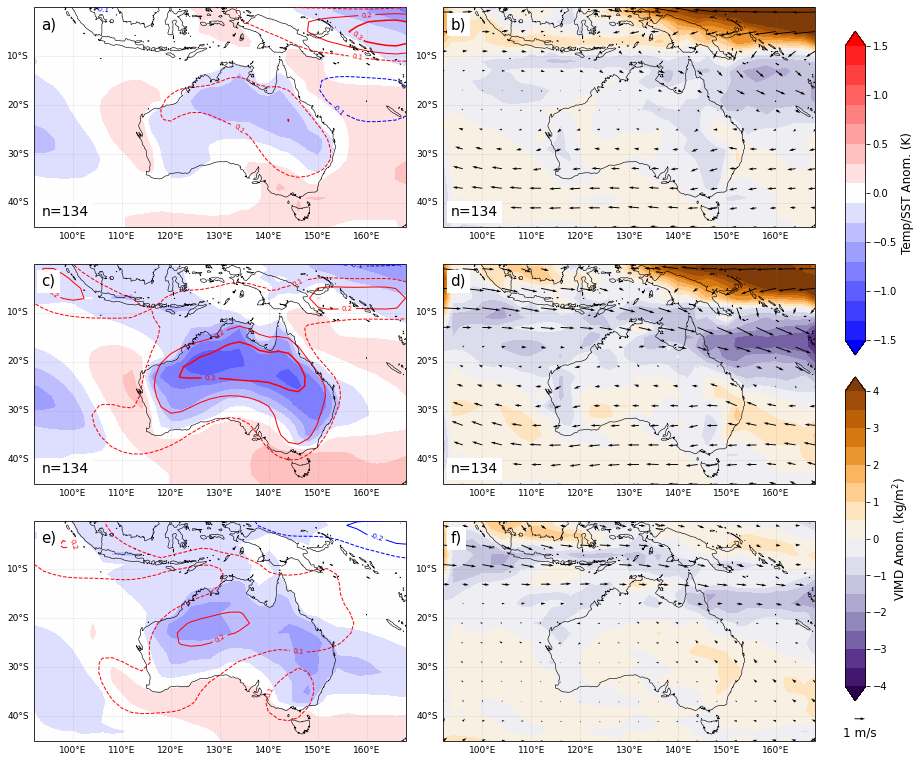

In [34]:
import matplotlib.colors as mcolors
from scipy.ndimage import gaussian_filter

# --- CONFIGURATION DES PARAMÈTRES ---
# Température & SST
# Définition manuelle pour une précision totale
lvl_temp = [-1.5, -1.3, -1.1, -0.9, -0.7, -0.5, -0.3, -0.1, 
             0.1,  0.3,  0.5,  0.7,  0.9,  1.1,  1.3,  1.5]

cmap_temp = plt.get_cmap('bwr')

# Le BoundaryNorm va mapper chaque intervalle de lvl_temp à une couleur du cmap
norm_temp = mcolors.BoundaryNorm(boundaries=lvl_temp, ncolors=cmap_temp.N, extend='both')

# VIMD (Converti en mm/jour ou kg/m2/jour, échelle centrée)
lvl_vimd = np.linspace(-4, 4, 17) 

# Évaporation — contours progressifs
lev_pos_dash   = [0.1]
lev_pos_thin   = [0.2]
lev_pos_thick  = [0.3]
lev_pos_vthick = [0.4]

lev_neg_dash   = [-0.1]
lev_neg_thin   = [-0.2]
lev_neg_thick  = [-0.3]
lev_neg_vthick = [-0.4]

# ============================================================
# FONCTIONS UTILITAIRES
# ============================================================

def smooth_data(da, sigma=1.5):
    """Lissage gaussien qui gère les NaNs."""
    v = da.values.copy()
    mask = np.isnan(v)
    v[mask] = 0
    v_smooth = gaussian_filter(v, sigma=sigma)
    v_smooth[mask] = np.nan
    return v_smooth

def format_map(ax, label, n_text):
    ax.set_extent([92, 168, -45, 0], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, color='black', zorder=10)
    ax.text(0.02, 0.9, label, transform=ax.transAxes, fontsize=15,
            bbox=dict(facecolor='white', edgecolor='none', alpha=1), zorder=11)
    if n_text is not None:
        ax.text(0.02, 0.05, f"n={n_text}", transform=ax.transAxes, fontsize=14,
                bbox=dict(facecolor='white', edgecolor='none', alpha=1), zorder=11)
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.3, linestyle='--')
    gl.top_labels = gl.right_labels = False
    gl.xlabel_style = gl.ylabel_style = {'size': 9}

# ============================================================
# CALCUL MMM
# ============================================================
seasonal_mmm = {tag_yr1: {}, tag_yr3: {}, tag_diff: {}}

for tag in [tag_yr1, tag_yr3]:
    for var in ['tas', 'tos', 'ev', 'u850', 'v850', 'vimd']:
        data_list = all_anoms.get(tag, {}).get(var, [])
        if len(data_list) > 0:
            da_concat = xr.concat(data_list, dim='model_event')
            seasonal_mmm[tag][var] = da_concat.mean(dim='model_event')
        else:
            print(f"⚠️ {tag} - {var} : Aucune donnée trouvée !")

for v in ['tas', 'tos', 'ev', 'u850', 'v850', 'vimd']:
    if v in seasonal_mmm[tag_yr3] and v in seasonal_mmm[tag_yr1]:
        seasonal_mmm[tag_diff][v] = seasonal_mmm[tag_yr3][v] - seasonal_mmm[tag_yr1][v]

# ============================================================
# FIGURE
# ============================================================
n_total_events = len(all_anoms[tag_yr1]['tas'])
print(f"\nNombre total d'événements pour le MMM ({SEASON}) : {n_total_events}")

periods       = [tag_yr1, tag_yr3, tag_diff]
labels_periods = [('a)', 'b)'), ('c)', 'd)'), ('e)', 'f)')]

fig, axes = plt.subplots(3, 2, figsize=(14, 15),
                         subplot_kw={'projection': ccrs.PlateCarree()})
plt.subplots_adjust(wspace=0.1, hspace=-0.15)
ax_list = axes.ravel()

for i, tag in enumerate(periods):
    ax_l, ax_r = ax_list[i * 2], ax_list[i * 2 + 1]
    lbl_l, lbl_r = labels_periods[i]
    n_ev = n_total_events if 'diff' not in tag else None

    format_map(ax_l, lbl_l, n_ev)
    format_map(ax_r, lbl_r, n_ev)

    # ----------------------------------------------------------
    # GAUCHE : TOS + TAS (shading) + ÉVAPORATION (contours)
    # ----------------------------------------------------------
    shading_kw = dict(
        transform=ccrs.PlateCarree(), levels=lvl_temp, norm=norm_temp,
        cmap='bwr', add_colorbar=False, add_labels=False, extend='both'
    )

    # SST (zorder=1, en dessous)
    im_temp = seasonal_mmm[tag]['tos'].plot.contourf(ax=ax_l, zorder=1, **shading_kw)
    # TAS par-dessus (zorder=2)
    seasonal_mmm[tag]['tas'].plot.contourf(ax=ax_l, zorder=2, **shading_kw)

    # Évaporation lissée
    ev_da     = seasonal_mmm[tag]['ev']
    ev_smooth = smooth_data(ev_da, sigma=1.5)
    lons, lats = ev_da.lon, ev_da.lat

    common_ev = dict(transform=ccrs.PlateCarree(), zorder=8)
    label_ev  = dict(inline=True, fontsize=7, fmt='%1.1f', inline_spacing=3)

    # Positifs (Rouge)
    cp1 = ax_l.contour(lons, lats, ev_smooth, levels=lev_pos_dash,   colors='red', linestyles='--', linewidths=1.0, **common_ev)
    cp2 = ax_l.contour(lons, lats, ev_smooth, levels=lev_pos_thin,   colors='red', linestyles='-',  linewidths=1.0, **common_ev)
    cp3 = ax_l.contour(lons, lats, ev_smooth, levels=lev_pos_thick,  colors='red', linestyles='-',  linewidths=1.5, **common_ev)
    cp4 = ax_l.contour(lons, lats, ev_smooth, levels=lev_pos_vthick, colors='red', linestyles='-',  linewidths=2.0, **common_ev)

    # Négatifs (Bleu)
    cn1 = ax_l.contour(lons, lats, ev_smooth, levels=lev_neg_dash,   colors='blue', linestyles='--', linewidths=1.0, **common_ev)
    cn2 = ax_l.contour(lons, lats, ev_smooth, levels=lev_neg_thin,   colors='blue', linestyles='-',  linewidths=1.0, **common_ev)
    cn3 = ax_l.contour(lons, lats, ev_smooth, levels=lev_neg_thick,  colors='blue', linestyles='-',  linewidths=1.5, **common_ev)
    cn4 = ax_l.contour(lons, lats, ev_smooth, levels=lev_neg_vthick, colors='blue', linestyles='-',  linewidths=2.0, **common_ev)

    for c in [cp1, cp2, cp3, cp4, cn1, cn2, cn3, cn4]:
        ax_l.clabel(c, **label_ev)

    # ----------------------------------------------------------
    # DROITE : VIMD (shading) + VENTS 850 hPa (vecteurs)
    # ----------------------------------------------------------
    im_vimd = seasonal_mmm[tag]['vimd'].plot.contourf(
        ax=ax_r, transform=ccrs.PlateCarree(), levels=lvl_vimd,
        cmap='PuOr_r', add_colorbar=False, add_labels=False, extend='both', zorder=1
    )

    u_p  = seasonal_mmm[tag]['u850']
    v_p  = seasonal_mmm[tag]['v850']
    skip = (slice(None, None, 2), slice(None, None, 2))

    Q = ax_r.quiver(
        u_p.lon.values[skip[1]], u_p.lat.values[skip[0]],
        u_p.values[skip], v_p.values[skip],
        scale=35, width=0.0025, color='black',
        transform=ccrs.PlateCarree(), zorder=10
    )

# ============================================================
# COLORBARS ET LÉGENDES
# ============================================================
cax1 = fig.add_axes([0.93, 0.52, 0.02, 0.3])
cb1 = fig.colorbar(im_temp, cax=cax1)
cb1.set_label('Temp/SST Anom. (K)', size=12)

# On définit explicitement les chiffres à afficher
cb1.set_ticks([-1.5, -1, -0.5, 0, 0.5, 1, 1.5])


cax2 = fig.add_axes([0.93, 0.2, 0.02, 0.3])
fig.colorbar(im_vimd, cax=cax2).set_label('VIMD Anom. (kg/m$^2$)', size=12)

# Quiverkey pour le vent
ax_list[5].quiverkey(Q, X=1.12, Y=0.1, U=1, label='1 m/s', labelpos='S', coordinates='axes', fontproperties={'size': 12})

fig.suptitle(f'Triple La Niña — Saison {SEASON}', fontsize=14, y=0.92)
#plt.savefig(f'/g/data/m35/qr1706/PhD-1_CMIP_analysis/png/ALL_Model_{SEASON}_Analysis+fin.png', dpi=300, bbox_inches='tight')
plt.show()

In [35]:
# ============================================================
# 1. PRÉPARATION DES DONNÉES (POUR LES DEUX SAISONS)
# ============================================================
seasons_list = ['SON', 'DJF']
periods_list = ['yr1', 'yr3', 'diff']
seasonal_mmm = {}

for SEAS in seasons_list:
    t1, t3, td = f'{SEAS}_yr1', f'{SEAS}_yr3', f'{SEAS}_diff'
    for tag in [t1, t3, td]: seasonal_mmm[tag] = {}
    
    for tag in [t1, t3]:
        for var in ['tas', 'tos', 'ev', 'u850', 'v850', 'vimd']:
            data_list = all_anoms.get(tag, {}).get(var, [])
            if len(data_list) > 0:
                seasonal_mmm[tag][var] = xr.concat(data_list, dim='model_event').mean(dim='model_event')

    for v in ['tas', 'tos', 'ev', 'u850', 'v850', 'vimd']:
        if v in seasonal_mmm[t3] and v in seasonal_mmm[t1]:
            seasonal_mmm[td][v] = seasonal_mmm[t3][v] - seasonal_mmm[t1][v]

/home/561/qr1706/.local/lib/python3.9/site-packages/cartopy/mpl/geoaxes.py:1604: UserWarning: No contour levels were found within the data range.
  result = super().contour(*args, **kwargs)
/home/561/qr1706/.local/lib/python3.9/site-packages/cartopy/mpl/geoaxes.py:1604: UserWarning: No contour levels were found within the data range.
  result = super().contour(*args, **kwargs)
/home/561/qr1706/.local/lib/python3.9/site-packages/cartopy/mpl/geoaxes.py:1604: UserWarning: No contour levels were found within the data range.
  result = super().contour(*args, **kwargs)
/home/561/qr1706/.local/lib/python3.9/site-packages/cartopy/mpl/geoaxes.py:1604: UserWarning: No contour levels were found within the data range.
  result = super().contour(*args, **kwargs)
/home/561/qr1706/.local/lib/python3.9/site-packages/cartopy/mpl/geoaxes.py:1604: UserWarning: No contour levels were found within the data range.
  result = super().contour(*args, **kwargs)
/home/561/qr1706/.local/lib/python3.9/site-package

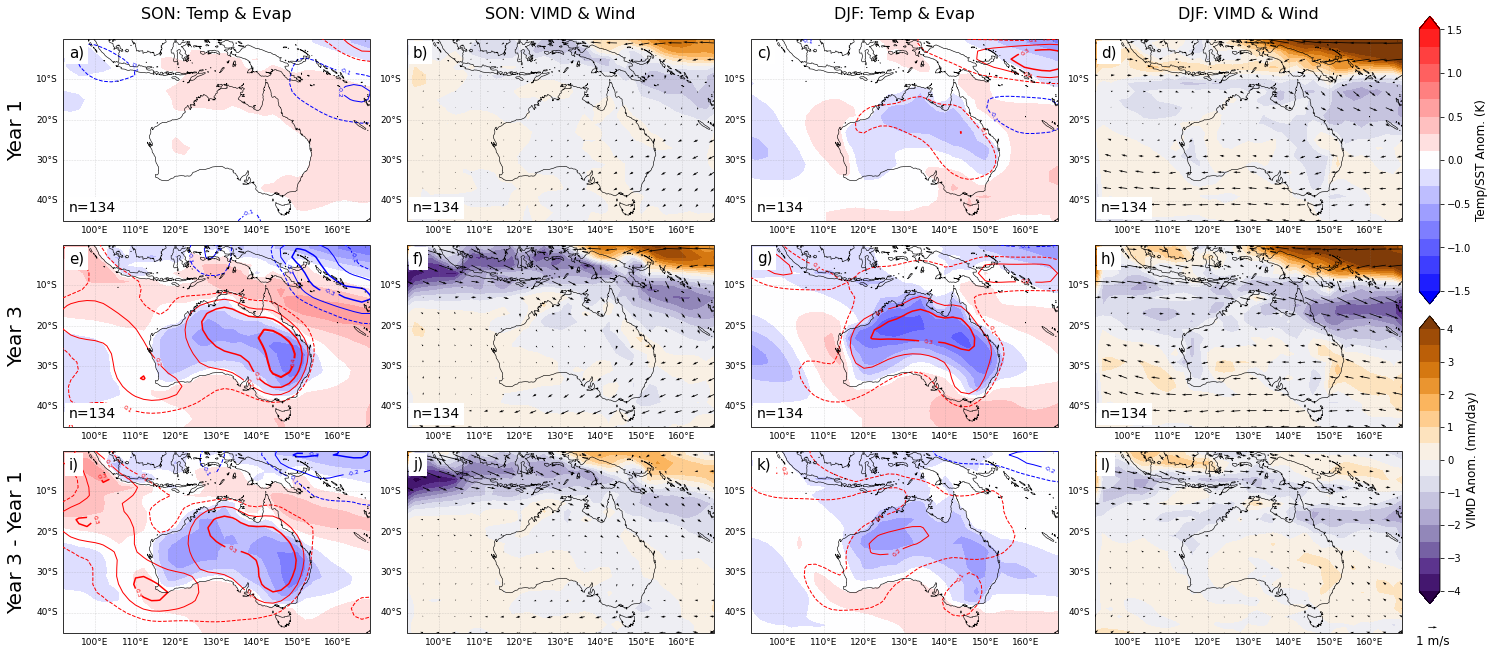

In [32]:
# ============================================================
# 2. CONSTRUCTION DE LA FIGURE (12 SUBPLOTS)
# ============================================================
fig, axes = plt.subplots(3, 4, figsize=(24, 16), subplot_kw={'projection': ccrs.PlateCarree()})
plt.subplots_adjust(wspace=0.12, hspace=-0.55)

row_titles = ["Year 1", "Year 3", "Year 3 - Year 1"]

# Labels pour les 12 figures
abc_labels = [['a)', 'b)', 'c)', 'd)'], 
              ['e)', 'f)', 'g)', 'h)'], 
              ['i)', 'j)', 'k)', 'l)']]


for r, period in enumerate(periods_list):
    
    # Ajout des titres de lignes (Vertical à gauche)
    # On utilise annotate pour un placement précis hors du cadre des cartes
    axes[r, 0].annotate(row_titles[r], xy=(-0.15, 0.5), xycoords='axes fraction',
                        fontsize=20, ha='center', va='center', rotation=90)
    
    for c_seas, SEAS in enumerate(seasons_list):
        tag = f"{SEAS}_{period}"
        n_ev = len(all_anoms[f"{SEAS}_yr1"]['tas']) if 'diff' not in period else None
        
        col_offset = c_seas * 2
        ax_l = axes[r, col_offset]     
        ax_r = axes[r, col_offset + 1] 
        
        format_map(ax_l, abc_labels[r][col_offset], n_ev)
        format_map(ax_r, abc_labels[r][col_offset+1], n_ev)

        # --- GAUCHE : TAS/TOS + EVAP ---
        shading_temp = dict(transform=ccrs.PlateCarree(), levels=lvl_temp, norm=norm_temp,
                            cmap='bwr', add_colorbar=False, add_labels=False, extend='both')
        
        seasonal_mmm[tag]['tos'].plot.contourf(ax=ax_l, zorder=1, **shading_temp)
        im_temp = seasonal_mmm[tag]['tas'].plot.contourf(ax=ax_l, zorder=2, **shading_temp)

        ev_smooth = smooth_data(seasonal_mmm[tag]['ev'], sigma=1.5)
        lons, lats = seasonal_mmm[tag]['ev'].lon, seasonal_mmm[tag]['ev'].lat
        common_ev = dict(transform=ccrs.PlateCarree(), zorder=8)
        
        for lv, lw in zip([lev_pos_dash, lev_pos_thin, lev_pos_thick, lev_pos_vthick], [1.0, 1.0, 1.5, 2.0]):
            cp = ax_l.contour(lons, lats, ev_smooth, levels=lv, colors='red', 
                              linestyles='--' if lv==[0.1] else '-', linewidths=lw, **common_ev)
            ax_l.clabel(cp, inline=True, fontsize=6, fmt='%1.1f')
            
        for lv, lw in zip([lev_neg_dash, lev_neg_thin, lev_neg_thick, lev_neg_vthick], [1.0, 1.0, 1.5, 2.0]):
            cn = ax_l.contour(lons, lats, ev_smooth, levels=lv, colors='blue', 
                              linestyles='--' if lv==[-0.1] else '-', linewidths=lw, **common_ev)
            ax_l.clabel(cn, inline=True, fontsize=6, fmt='%1.1f')

        # --- DROITE : VIMD + VENTS ---
        im_vimd = seasonal_mmm[tag]['vimd'].plot.contourf(
            ax=ax_r, transform=ccrs.PlateCarree(), levels=lvl_vimd,
            cmap='PuOr_r', add_colorbar=False, add_labels=False, extend='both', zorder=1
        )
        
        u, v = seasonal_mmm[tag]['u850'], seasonal_mmm[tag]['v850']
        skip = (slice(None, None, 2), slice(None, None, 2))
        Q = ax_r.quiver(u.lon.values[skip[1]], u.lat.values[skip[0]], u.values[skip], v.values[skip],
                        scale=35, width=0.0025, color='black', transform=ccrs.PlateCarree(), zorder=10)

# ============================================================
# 3. COLORBARS ET TITRES FINAUX
# ============================================================
# Titres de colonnes
axes[0, 0].set_title("SON: Temp & Evap", fontsize=16, pad=20)
axes[0, 1].set_title("SON: VIMD & Wind", fontsize=16, pad=20)
axes[0, 2].set_title("DJF: Temp & Evap", fontsize=16, pad=20)
axes[0, 3].set_title("DJF: VIMD & Wind", fontsize=16, pad=20)

# Colorbars
cax1 = fig.add_axes([0.91, 0.53, 0.012, 0.25])
cb1 = fig.colorbar(im_temp, cax=cax1)
cb1.set_label('Temp/SST Anom. (K)', size=12)
cb1.set_ticks([-1.5, -1, -0.5, 0, 0.5, 1, 1.5])

cax2 = fig.add_axes([0.91, 0.27, 0.012, 0.25])
fig.colorbar(im_vimd, cax=cax2).set_label('VIMD Anom. (mm/day)', size=12)

# Quiverkey
axes[2, 3].quiverkey(Q, X=1.1, Y=0.03, U=1, label='1 m/s', labelpos='S', coordinates='axes', fontproperties={'size': 12})

plt.savefig(f'/g/data/m35/qr1706/PhD-1_CMIP_analysis/png/SON_DJF_Fours-y-tout.png', dpi=300, bbox_inches='tight')
plt.show()

In [36]:
# ============================================================
# 1. PRÉPARATION DES DONNÉES (MMM AVEC POIDS ÉGAL PAR MODÈLE)
# ============================================================
seasons_list = ['SON', 'DJF']
periods_list = ['yr1', 'yr3', 'diff']
vars_to_plot = ['tas', 'tos', 'ev', 'u850', 'v850', 'vimd']
seasonal_mmm = {}

for SEAS in seasons_list:
    t1, t3, td = f'{SEAS}_yr1', f'{SEAS}_yr3', f'{SEAS}_diff'
    for tag in [t1, t3, td]: 
        seasonal_mmm[tag] = {}
    
    # Calcul pour yr1 et yr3
    for tag in [t1, t3]:
        files = sorted(glob.glob(os.path.join(save_dir, f"*_{tag}_anoms.nc")))
        
        for var in vars_to_plot:
            model_means = []
            
            for f in files:
                ds = xr.open_dataset(f)
                if var in ds:
                    # Moyenne des événements pour CE modèle précis
                    # On utilise dim='event_year' car c'est le nom dans tes fichiers .nc
                    model_mean = ds[var].mean(dim='event_year', skipna=True)
                    model_means.append(model_mean)
                ds.close()
            
            if model_means:
                # Moyenne des moyennes : chaque modèle compte pour 1
                da_models = xr.concat(model_means, dim='model')
                seasonal_mmm[tag][var] = da_models.mean(dim='model', skipna=True)

    # Calcul de la différence (Year 3 - Year 1)
    for v in vars_to_plot:
        if v in seasonal_mmm[t3] and v in seasonal_mmm[t1]:
            seasonal_mmm[td][v] = seasonal_mmm[t3][v] - seasonal_mmm[t1][v]

/home/561/qr1706/.local/lib/python3.9/site-packages/cartopy/mpl/geoaxes.py:1604: UserWarning: No contour levels were found within the data range.
  result = super().contour(*args, **kwargs)
/home/561/qr1706/.local/lib/python3.9/site-packages/cartopy/mpl/geoaxes.py:1604: UserWarning: No contour levels were found within the data range.
  result = super().contour(*args, **kwargs)
/home/561/qr1706/.local/lib/python3.9/site-packages/cartopy/mpl/geoaxes.py:1604: UserWarning: No contour levels were found within the data range.
  result = super().contour(*args, **kwargs)
/home/561/qr1706/.local/lib/python3.9/site-packages/cartopy/mpl/geoaxes.py:1604: UserWarning: No contour levels were found within the data range.
  result = super().contour(*args, **kwargs)
/home/561/qr1706/.local/lib/python3.9/site-packages/cartopy/mpl/geoaxes.py:1604: UserWarning: No contour levels were found within the data range.
  result = super().contour(*args, **kwargs)
/home/561/qr1706/.local/lib/python3.9/site-package

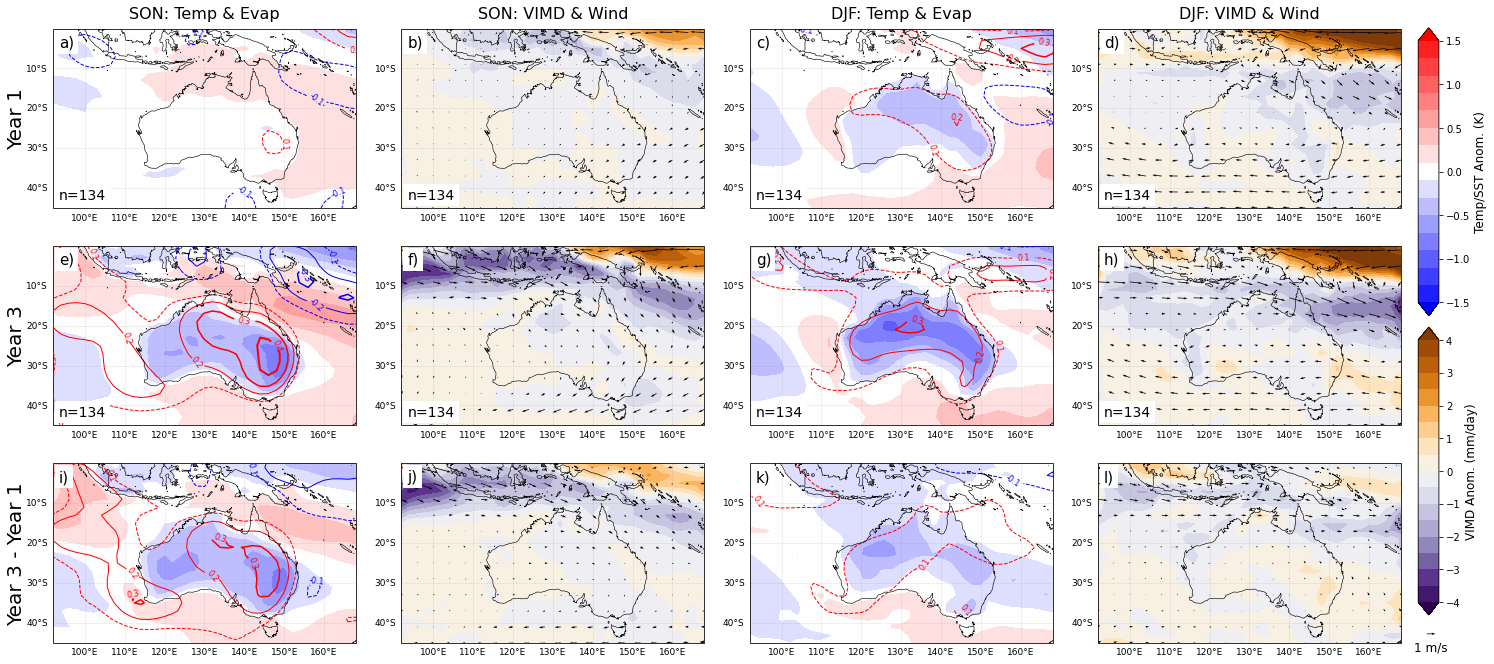

In [41]:
# ============================================================
# 2. CONSTRUCTION DE LA FIGURE (12 SUBPLOTS)
# ============================================================
fig, axes = plt.subplots(3, 4, figsize=(24, 16), subplot_kw={'projection': ccrs.PlateCarree()})
# Ajustement manuel pour laisser de la place aux titres verticaux et colorbars
plt.subplots_adjust(wspace=0.15, hspace=-0.50, left=0.12, right=0.90)

row_titles = ["Year 1", "Year 3", "Year 3 - Year 1"]
abc_labels = [['a)', 'b)', 'c)', 'd)'], 
              ['e)', 'f)', 'g)', 'h)'], 
              ['i)', 'j)', 'k)', 'l)']]

for r, period in enumerate(periods_list):
    
    axes[r, 0].annotate(row_titles[r], xy=(-0.12, 0.5), xycoords='axes fraction',
                        fontsize=20, ha='center', va='center', rotation=90)
    
    for c_seas, SEAS in enumerate(seasons_list):
        tag = f"{SEAS}_{period}"
        
        # --- CALCUL DU NOMBRE TOTAL D'ÉVÉNEMENTS (Somme de tous les modèles) ---
        if 'diff' not in period:
            files = glob.glob(os.path.join(save_dir, f"*_{SEAS}_{period}_anoms.nc"))
            total_ev = 0
            for f in files:
                with xr.open_dataset(f) as ds:
                    total_ev += len(ds.event_year.values)
            n_text = total_ev
        else:
            n_text = None
        
        col_offset = c_seas * 2
        ax_l = axes[r, col_offset]     
        ax_r = axes[r, col_offset + 1] 
        
        format_map(ax_l, abc_labels[r][col_offset], n_text)
        format_map(ax_r, abc_labels[r][col_offset+1], n_text)

        # --- GAUCHE : TAS/TOS + EVAP ---
        shading_temp = dict(transform=ccrs.PlateCarree(), levels=lvl_temp, norm=norm_temp,
                            cmap='bwr', add_colorbar=False, add_labels=False, extend='both')
        
        seasonal_mmm[tag]['tos'].plot.contourf(ax=ax_l, zorder=1, **shading_temp)
        im_temp = seasonal_mmm[tag]['tas'].plot.contourf(ax=ax_l, zorder=2, **shading_temp)

        ev_smooth = smooth_data(seasonal_mmm[tag]['ev'], sigma=1.5)
        lons, lats = seasonal_mmm[tag]['ev'].lon, seasonal_mmm[tag]['ev'].lat
        common_ev = dict(transform=ccrs.PlateCarree(), zorder=8)
        
        # Contours Évaporation
        for lv, lw in zip([lev_pos_dash, lev_pos_thin, lev_pos_thick, lev_pos_vthick], [1.0, 1.0, 1.5, 2.0]):
            cp = ax_l.contour(lons, lats, ev_smooth, levels=lv, colors='red', 
                              linestyles='--' if lv==[0.1] else '-', linewidths=lw, **common_ev)
            ax_l.clabel(cp, inline=True, fontsize=8, fmt='%1.1f')
            
        for lv, lw in zip([lev_neg_dash, lev_neg_thin, lev_neg_thick, lev_neg_vthick], [1.0, 1.0, 1.5, 2.0]):
            cn = ax_l.contour(lons, lats, ev_smooth, levels=lv, colors='blue', 
                              linestyles='--' if lv==[-0.1] else '-', linewidths=lw, **common_ev)
            ax_l.clabel(cn, inline=True, fontsize=8, fmt='%1.1f')

        # --- DROITE : VIMD + VENTS ---
        im_vimd = seasonal_mmm[tag]['vimd'].plot.contourf(
            ax=ax_r, transform=ccrs.PlateCarree(), levels=lvl_vimd,
            cmap='PuOr_r', add_colorbar=False, add_labels=False, extend='both', zorder=1
        )
        
        u, v = seasonal_mmm[tag]['u850'], seasonal_mmm[tag]['v850']
        skip = (slice(None, None, 2), slice(None, None, 2))
        Q = ax_r.quiver(u.lon.values[skip[1]], u.lat.values[skip[0]], u.values[skip], v.values[skip],
                        scale=35, width=0.0025, color='black', transform=ccrs.PlateCarree(), zorder=10)

# ============================================================
# 3. COLORBARS ET TITRES FINAUX
# ============================================================
axes[0, 0].set_title("SON: Temp & Evap", fontsize=16, pad=10)
axes[0, 1].set_title("SON: VIMD & Wind", fontsize=16, pad=10)
axes[0, 2].set_title("DJF: Temp & Evap", fontsize=16, pad=10)
axes[0, 3].set_title("DJF: VIMD & Wind", fontsize=16, pad=10)

cax1 = fig.add_axes([0.91, 0.52, 0.012, 0.25])
cb1 = fig.colorbar(im_temp, cax=cax1)
cb1.set_label('Temp/SST Anom. (K)', size=12)
cb1.set_ticks([-1.5, -1, -0.5, 0, 0.5, 1, 1.5])

cax2 = fig.add_axes([0.91, 0.26, 0.012, 0.25])
fig.colorbar(im_vimd, cax=cax2).set_label('VIMD Anom. (mm/day)', size=12)

axes[2, 3].quiverkey(Q, X=1.1, Y=0.05, U=1, label='1 m/s', labelpos='S', coordinates='axes', fontproperties={'size': 12})

plt.savefig(f'/g/data/m35/qr1706/PhD-1_CMIP_analysis/png/SON_DJF_Foursytout_MMM.png', dpi=300, bbox_inches='tight')
plt.show()